# Gym Churn: Data Preparation and EDA

This notebook loads and checks the Model Fitness customer data, then explores how customers who churned differ from those who stayed.

In [1]:
# Libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)  # show all columns in outputs

## 1. Data Preparation

In [2]:
# Load the customer dataset
gym_data = pd.read_csv('../data/gym_churn_us.csv')

In [3]:
# Dataset size and first rows
print(gym_data.shape)
gym_data.head()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
# Data types and non-null counts per column
gym_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [5]:
# Check data quality: missing values and duplicated rows
print("Missing values:", gym_data.isna().sum().sum())
print("Duplicated rows:", gym_data.duplicated().sum())

Missing values: 0
Duplicated rows: 0


In [6]:
# Standardize column names to lowercase for consistency
gym_data.columns = gym_data.columns.str.lower()
gym_data.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='str')

In [7]:
# Check the values in the 'month_to_end_contract' column
gym_data['month_to_end_contract'].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])

In [8]:
# All values are whole months, so convert to int
gym_data['month_to_end_contract'] = gym_data['month_to_end_contract'].astype(
    int)
gym_data['month_to_end_contract'].dtype

dtype('int64')

In [9]:
# Confirm the available contract lengths (in months)
gym_data['contract_period'].value_counts()

contract_period
1     2207
12     960
6      833
Name: count, dtype: int64

In [10]:
# Check that binary features only contain 0 and 1
binary_cols = ['gender', 'near_location', 'partner', 'promo_friends',
               'phone', 'group_visits', 'churn']

for col in binary_cols:
    print(col, gym_data[col].sort_values().unique())

gender [0 1]
near_location [0 1]
partner [0 1]
promo_friends [0 1]
phone [0 1]
group_visits [0 1]
churn [0 1]


### Observations
- The dataset has 4,000 customers and 14 numeric features, with no missing values or duplicates.
- Column names were converted to lowercase, and `month_to_end_contract` was converted to int since it only holds whole months. 
- Binary features (gender, near_location, partner, promo_friends, phone, group_visits, churn) only contain 0 and 1. They are kept as integers rather than booleans: their mean directly gives the share of customers with each characteristic, and the models used later require numeric inputs.
- The meaning of the `gender` values (0/1) is not documented in the project description, so this feature is interpreted only as two groups without assigning labels.

## 2. Exploratory Data Analysis

In [11]:
# Plot the distribution of a feature for customers who stayed vs churned
def plot_churn_distribution(data, col, label):
    # Readable labels for the churn groups in the legend
    plot_data = data.copy()
    plot_data['status'] = plot_data['churn'].map({0: 'Stayed', 1: 'Churned'})

    plt.figure(figsize=(8, 4))
    sns.histplot(data=plot_data, x=col, hue='status', stat='density',
                 common_norm=False, kde=True,
                 discrete=(data[col].dtype == 'int64'))
    plt.title(f'{label} by Churn Status')
    plt.xlabel(label)
    plt.ylabel('Density')
    plt.show()

In [12]:
# Summary statistics per feature: mean, std, min/max and quartiles
gym_data.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


In [13]:
# Average feature values for customers who stayed (0) and who churned (1)
gym_data.groupby('churn').mean().T

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


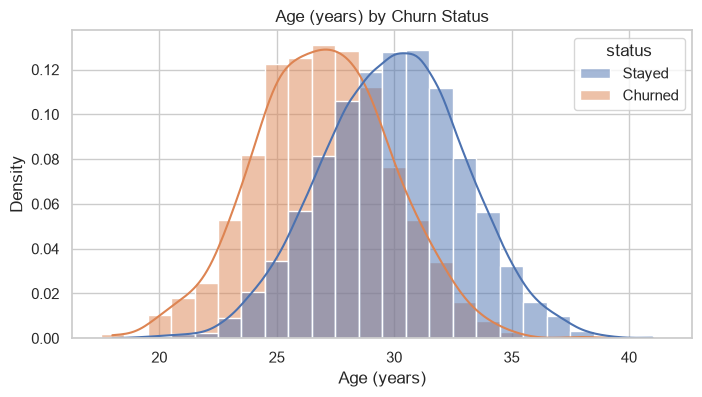

In [14]:
plot_churn_distribution(gym_data, 'age', 'Age (years)')

**Age:**
- Churned customers are younger, peaking around 26–28 years versus 30–31 for those who stayed.
- The distributions overlap considerably between 25 and 33, so age alone does not separate the groups well.
- Most customers under 23 churned, while almost all over 34 stayed.

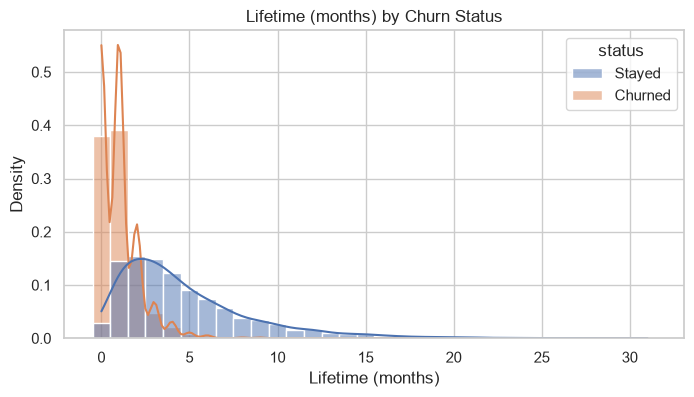

In [15]:
plot_churn_distribution(gym_data, 'lifetime', 'Lifetime (months)')

**Lifetime:**
- Churn is concentrated in the first months: most churned customers have a lifetime of 0–1 months.
- The distribution for customers who stayed peaks at 2–3 months and then declines gradually, as fewer customers reach longer lifetimes.
- Customers who stay past the first 2–3 months are much less likely to leave, making the first weeks the critical period for retention..

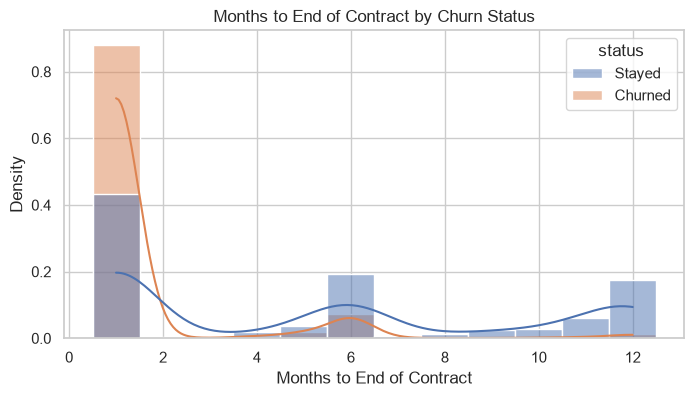

In [16]:
plot_churn_distribution(gym_data, 'month_to_end_contract',
                        'Months to End of Contract')

**Month to end contract:**
- Churn is concentrated among customers whose contract is about to end (1 month remaining), which includes all customers on 1-month contracts.
- Customers with many months remaining (6 or 12) rarely churn, as they are still at the start of a longer commitment.
- A small share of churned customers had 6 months remaining, showing that longer contracts reduce churn risk but do not eliminate it.

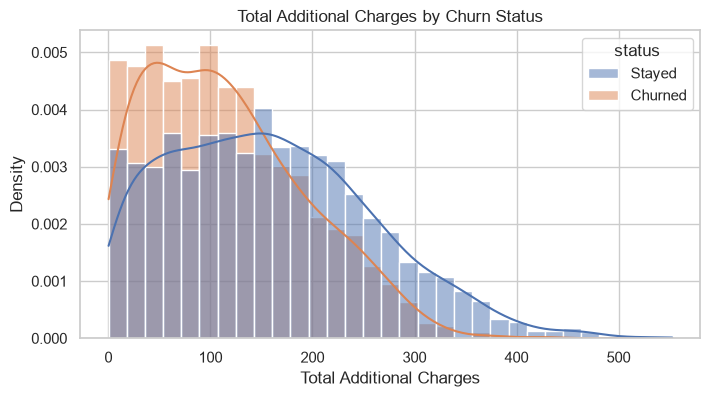

In [17]:
plot_churn_distribution(
    gym_data, 'avg_additional_charges_total', 'Total Additional Charges')

**Additional charges:**
- Customers who stayed tend to spend more on additional services, while churned customers are concentrated at lower spending levels.
- The distributions overlap considerably, so the effect is moderate compared to lifetime or contract features.
- Since this is a cumulative total, part of the difference may be explained by churned customers having a much shorter lifetime, and therefore less time to spend.

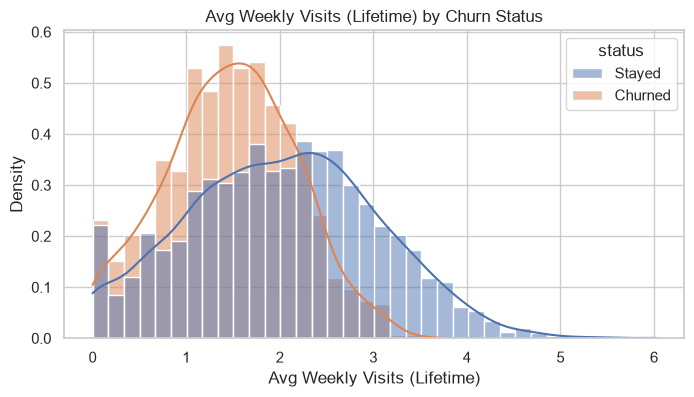

In [18]:
plot_churn_distribution(
    gym_data, 'avg_class_frequency_total', 'Avg Weekly Visits (Lifetime)')

**Average visit frequency (total):**
- Customers who stayed visit the gym more often, peaking around 2.3–2.5 visits per week versus about 1.5 for those who churned.
- The distributions overlap at lower frequencies, but above roughly 3 visits per week almost no customers churned.
- Visit frequency has a moderate effect on its own, with high frequency strongly associated with retention.

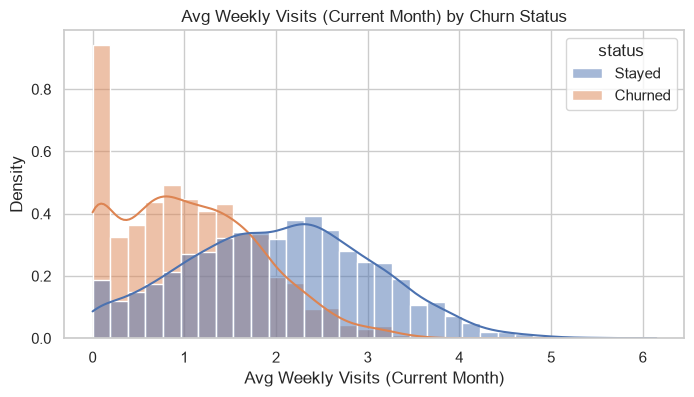

In [19]:
plot_churn_distribution(
    gym_data, 'avg_class_frequency_current_month', 'Avg Weekly Visits (Current Month)')

**Average visit frequency (current month):**
- The separation is much clearer than for the total frequency: churned customers are concentrated between 0 and 1.5 visits per week, and a large share did not visit at all this month.
- Customers who stayed kept their usual frequency (around 2 visits per week), while churned customers dropped from about 1.5 (total) to about 1 (current month), as seen in the group means.
- A drop in visit frequency compared to a customer's usual level is an early warning sign of churn.